# **📌 Import**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
# from sklearn.naive_bayes import 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from wordcloud import WordCloud

from tqdm import tqdm
import warnings
import sys
warnings.filterwarnings('ignore')
# Thiết lập style cho matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sklearn.set_config(enable_metadata_routing=True)

In [2]:
sys.path.append("..")
from modules import tabular, text_lib
import importlib

# **📥 Download Dataset**

In [3]:
import kagglehub
import os
import shutil

data_dir = "../data/emotion_detection/"
raw_data_dir = os.path.join(data_dir, "raw_data/")
data_file_name = "tweet_emotions.csv"
features_dir = os.path.join(data_dir, "features/")
model_result_path = os.path.join(data_dir, "model_result/")

In [4]:
os.makedirs(data_dir, exist_ok=True)
os.makedirs(features_dir, exist_ok=True)


if os.path.exists(os.path.join(raw_data_dir, data_file_name)):
    print("Data file exists.")
else:
    path = kagglehub.dataset_download(
        handle="pashupatigupta/emotion-detection-from-text"
    )
    src = os.path.join(path, data_file_name)
    os.makedirs(raw_data_dir, exist_ok=True)
    shutil.copy(src, raw_data_dir)

print("Path to data:", os.path.join(raw_data_dir, data_file_name))

Data file exists.
Path to data: ../data/emotion_detection/raw_data/tweet_emotions.csv


In [5]:
df = pd.read_csv(os.path.join(raw_data_dir, data_file_name))
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


# **📊 EDA**

In [6]:
tabular.dataset_info(df=df)


Dataset Info:
Total samples: 40,000
Features: 3
Data Shape: (40000, 3)
Columns: Index(['tweet_id', 'sentiment', 'content'], dtype='object')
Dtypes:
 tweet_id      int64
sentiment    object
content      object
dtype: object


In [7]:
tabular.missing_report(df)

Missing Value:
           Missing  Percent
tweet_id         0      0.0
sentiment        0      0.0
content          0      0.0


In [8]:
tabular.column_report(df)

Column Report:
           Dtypes  Nunique
tweet_id    int64    40000
sentiment  object       13
content    object    39827


In [9]:
df = df.drop_duplicates(subset=["content"])
df = df.drop(columns=["tweet_id"])

In [10]:
df["text_len"] = df["content"].apply(func=lambda x: len(x))
df

,sentiment,content,text_len
0,empty,@tiffanylue i know i was listenin to bad habi...,92
1,sadness,Layin n bed with a headache ughhhh...waitin o...,60
2,sadness,Funeral ceremony...gloomy friday...,35
3,enthusiasm,wants to hang out with friends SOON!,36
4,neutral,@dannycastillo We want to trade with someone w...,86
...,...,...,...
39995,neutral,@JohnLloydTaylor,16
39996,love,Happy Mothers Day All my love,30
39997,love,Happy Mother's Day to all the mommies out ther...,123
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,122


In [11]:
_, text_len_report = tabular.numeric_stat_report(df)
text_len_report

,text_len
count,39827.000000
mean,73.530821
std,36.490448
min,1.000000
25%,43.000000
50%,69.000000
75%,103.000000
max,167.000000


[('normal', 'text_len')]


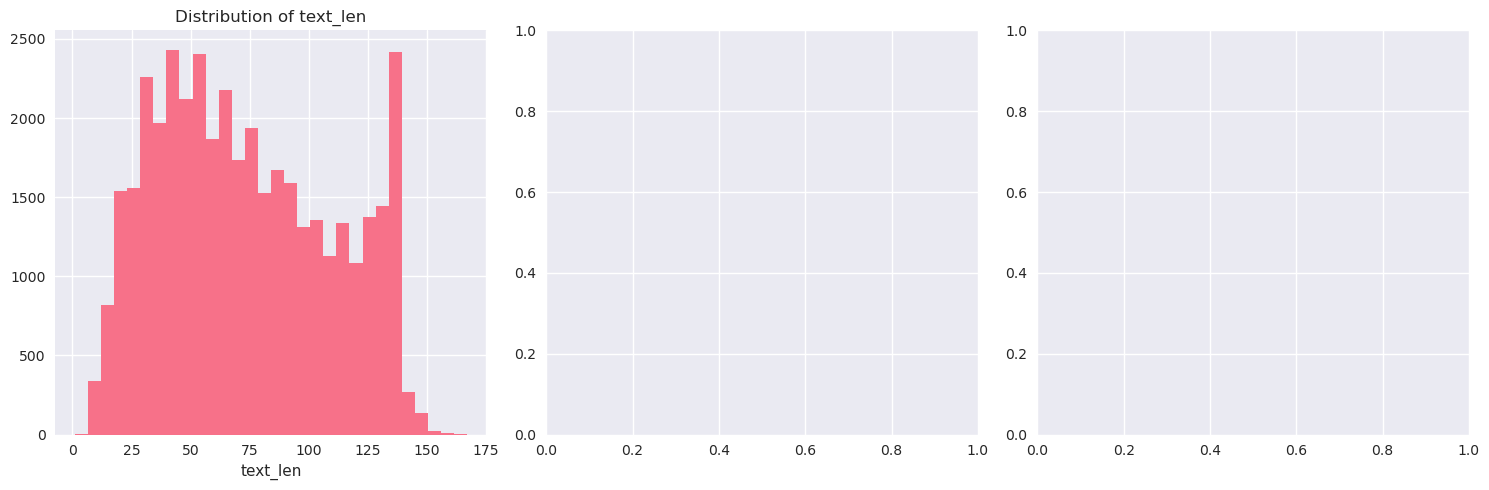

In [12]:
tabular.numeric_plot(df=df, config=None, plot="histogram")

[('normal', 'text_len')]


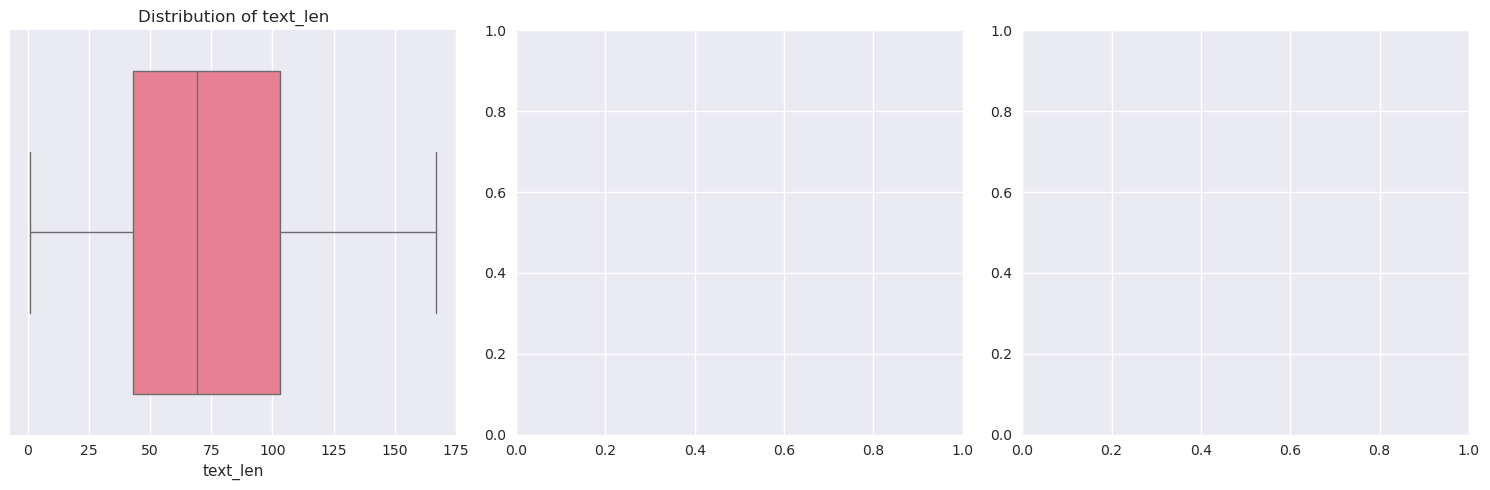

In [13]:
tabular.numeric_plot(df=df, config=None, plot="boxplot")

In [14]:
# Bag of words thô
def normal_bow(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

counter = Counter()
for text in df["content"]:
    counter.update(normal_bow(text))

In [15]:
normal_bow_df = pd.DataFrame(counter.items(), columns=["word", "count"])
normal_bow_df.sort_values("count", ascending=False)

,word,count
1,i,18980
5,to,14329
101,the,12847
19,a,9613
54,my,7972
...,...,...
53597,consummate,1
53596,frolic,1
53595,iscreamshinki,1
53594,astronick,1


In [16]:
print("Rare words (count = 1):", sum(normal_bow_df["count"] == 1))

Rare words (count = 1): 38706


In [17]:
df = text_lib.special_text_count(df)

Special key count: 144828
Mention (@) count: 19991
Hashtag (#) count: 920
Link count: 1804


In [18]:
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /home/nhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
df, word_freq = text_lib.advanced_bow_eda(df, stop_words)

In [20]:
df

,sentiment,content,text_len,special_count,mention_count,hashtag_count,link_count,tokens
0,empty,@tiffanylue i know i was listenin to bad habi...,92,3,1,0,0,"[know, listenin, bad, habit, earlier, started,..."
1,sadness,Layin n bed with a headache ughhhh...waitin o...,60,6,0,0,0,"[layin, n, bed, headache, ughhhhwaitin, call]"
2,sadness,Funeral ceremony...gloomy friday...,35,6,0,0,0,"[funeral, ceremonygloomy, friday]"
3,enthusiasm,wants to hang out with friends SOON!,36,1,0,0,0,"[wants, hang, friends, soon]"
4,neutral,@dannycastillo We want to trade with someone w...,86,2,1,0,0,"[want, trade, someone, houston, tickets, one]"
...,...,...,...,...,...,...,...,...
39995,neutral,@JohnLloydTaylor,16,1,1,0,0,[]
39996,love,Happy Mothers Day All my love,30,0,0,0,0,"[happy, mothers, day, love]"
39997,love,Happy Mother's Day to all the mommies out ther...,123,5,0,0,0,"[happy, mothers, day, mommies, woman, man, lon..."
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,122,12,1,0,0,"[wassup, beautiful, follow, peep, new, hit, si..."


In [21]:
advanced_bow_df = pd.DataFrame(word_freq.items(), columns=["word", "count"])
advanced_bow_df.sort_values("count", ascending=False)

,word,count
35,im,4407
204,day,2990
291,good,2243
59,get,1999
33,like,1928
...,...,...
33783,quotghosts,1
33784,goooodnight,1
33785,kingdomquot,1
33786,ayehe,1


In [22]:
print("Rare words (count = 1):", sum(advanced_bow_df["count"] == 1))

Rare words (count = 1): 21351


EDA Label

[('normal', 'sentiment'), ('top_10', 'sentiment')]


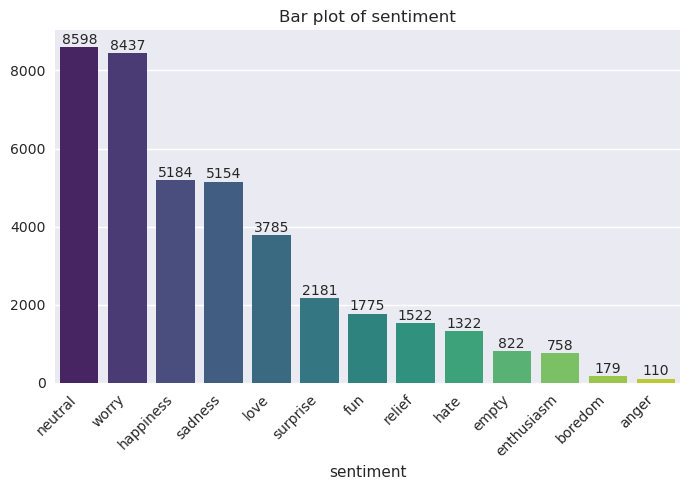

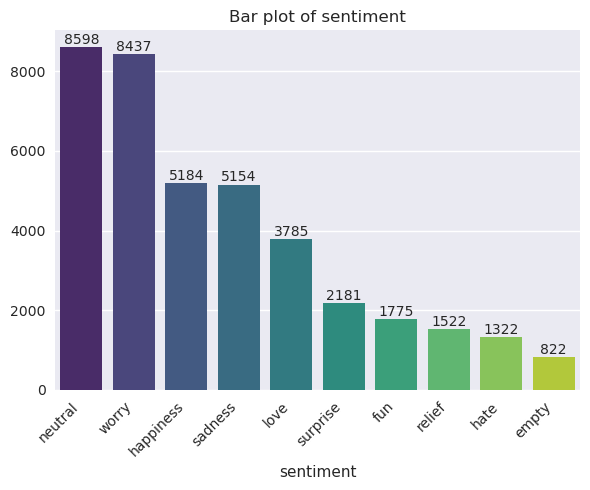

In [23]:
tabular.categorical_plot(df=df, config={"normal": ["sentiment"], "top_10": ["sentiment"]}, plot="barplot")

# **Preprocessing**

In [24]:
X = df["content"]
y = df["sentiment"]

In [25]:
X_clean = text_lib.text_preprocess(df=X, stop_words=stop_words)
X_clean

['know listenin bad habit earlier started freakin part',
 'layin n bed headache ughhhhwaitin call',
 'funeral ceremonygloomy friday',
 'wants hang friends soon',
 'want trade someone houston tickets one',
 'repinging didnt go prom bc bf didnt like friends',
 'sleep im thinking old friend want hes married damn amp wants scandalous',
 'hmmm',
 'charlene love miss',
 'im sorry least friday',
 'cant fall asleep',
 'choked retainers',
 'ugh beat stupid song get next rude',
 'u watch hills london u realise tourture weeks weeks late watch itonlinelol',
 'got news',
 'storm electricity gone',
 'agreed',
 'sleepy even late fail',
 'lady gaga tweeted impressed video leaking know',
 'convinced always wanted signals give offdamn think lost another friend',
 'oh bad hope gets better ive sleep issues lately',
 'wondering im awake amwriting new songplotting evil secret plots muahahahaoh damn itnot secret anymore',
 'topic maps talks balisage markup conference program online via',
 'ate something dont

In [26]:
target_encoder = OrdinalEncoder()
y_clean = target_encoder.fit_transform(y.values.reshape(-1, 1))
y_clean

array([[ 2.],
       [10.],
       [10.],
       ...,
       [ 7.],
       [ 5.],
       [ 7.]], shape=(39827, 1))

# **Train & Test split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y)

In [28]:
X_train

['woot interview went awsome didnt get talk mr johnny thought oh well still really good',
 'jimithy cant come msbjlt',
 'couple days sheeeeit wish something cafe claude',
 'people following people follow please x',
 'wanted go clubdancingbut im tired anyways go work tomorrow',
 'saw tour months ago boston good glad finally got see',
 'revise bit back soon',
 'hates sat around alone friday night big sad old loser',
 'awww daddy got car accident pray hes shookn lil',
 'hey handsome im packing',
 'dudes cmon thats almost ghey',
 'support trust honor moms support health happy moms day',
 'looks nice never knew vhs short life span hope fav vhs dead',
 'spanish suckiest class ever im learning atleast te quiero tiasha',
 'ahhh feel sorry little girl cant watch crying xx',
 'aww minutes left family guy',
 'ty much ff',
 'oh noes tv broken red standby light anything checked plug fuse inside',
 'wheres bridge need one fuck',
 'picnic table cruet set',
 'love fact bank holiday monday stay bed',
 

# **Feature Extraction**

In [29]:
pipe = text_lib.build_text_pipeline()

In [30]:
default_features_dir = os.path.join(features_dir, "default/")
os.makedirs(default_features_dir, exist_ok=True)

if not os.path.exists(os.path.join(default_features_dir, "train.npy")):
    X_train_features = pipe.fit_transform(X_train)
    np.save(os.path.join(default_features_dir, "train"), X_train_features)

if not os.path.exists(os.path.join(default_features_dir, "test.npy")):
    X_test_features = pipe.transform(X_test)
    np.save(os.path.join(default_features_dir, "test"),  X_test_features)

# print(f"X_train_features shape: {X_train_features.shape}, X_test_features shape: {X_test_features.shape}")

# **Train & Evaluate Model**


In [31]:
from sklearn.model_selection import ParameterGrid
# Model chosing
param_grid = [
    {
        "model": [LogisticRegression(random_state=42)],
    },
    {
        "model": [RandomForestClassifier(max_depth=100, random_state=42)],
    },
    # {
    #     "model": [SVC()], # Take too long to train
    # },
    {
        "model": [MLPClassifier(random_state=42)],
    },
    {
        "model": [MultinomialNB()]
    }
]
grid = ParameterGrid(param_grid=param_grid)

In [32]:
TRAIN = False # Multi train later

In [33]:
if TRAIN:
    results = []

    X_train = np.load(os.path.join(default_features_dir, "train.npy"))
    X_test = np.load(os.path.join(default_features_dir, "test.npy"))

    for params in grid:
        # Tạo pipeline với model tương ứng
        pipe = Pipeline([
            # ("preprocess", preprocessing_pipeline),
            ("model", params["model"])
        ])
        pipe.set_params(**params)
        pipe.set_output(transform="pandas")

        print(f"Training {params["model"].__class__.__name__}...")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred, average="weighted")
        recall = recall_score(y_test, y_pred, average="weighted")
        f1  = f1_score(y_test, y_pred, average="weighted")

        # Lưu kết quả
        results.append({
            "Params": params["model"].__class__.__name__,
            "accuracy": acc,
            "precision": pre,
            "recall": recall,
            "f1": f1
        })
        print(results[-1])

    # Xuất kết quả ra DataFrame
    df_results = pd.DataFrame(results)
    print(df_results)

In [34]:
# os.makedirs(model_result_path, exist_ok=True)
# df_results.to_csv(os.path.join(model_result_path, "test"))

# **Autotrain model with multi config preprocess & embedding**

In [35]:
preprocess_fe_config = [
    {
        "tokenizer": tokenizer,
        "remove_stopwords": remove_stopwords,
        # "lemmatize": lemmatize,
        # "embedding": embedding,
        "max_features": max_features
    }
    for tokenizer in ["split", "nltk"]
    for remove_stopwords in [True, False]
    # for lemmatize in [True, False]
    # for embedding in ["bow", 'tfidf']
    for max_features in [1500, 2000, 2500, 3000]
] # 1.5gb data for 1 config -> 16 config = 24gb

In [36]:
main_data = df[["content", "sentiment"]]
main_data

,content,sentiment
0,@tiffanylue i know i was listenin to bad habi...,empty
1,Layin n bed with a headache ughhhh...waitin o...,sadness
2,Funeral ceremony...gloomy friday...,sadness
3,wants to hang out with friends SOON!,enthusiasm
4,@dannycastillo We want to trade with someone w...,neutral
...,...,...
39995,@JohnLloydTaylor,neutral
39996,Happy Mothers Day All my love,love
39997,Happy Mother's Day to all the mommies out ther...,love
39998,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,happiness


In [37]:
split_dataset = text_lib.multi_preprocess_fe(
    preprocess_fe_config,
    main_data,
    "sentiment",
    os.path.join(features_dir, "multi_1/")
)

In [38]:
split_dataset

,tokenizer,remove_stopwords,max_features,save_path
0,split,True,1500,../data/emotion_detection/features/multi_1/tok...
1,split,True,2000,../data/emotion_detection/features/multi_1/tok...
2,split,True,2500,../data/emotion_detection/features/multi_1/tok...
3,split,True,3000,../data/emotion_detection/features/multi_1/tok...
4,split,False,1500,../data/emotion_detection/features/multi_1/tok...
5,split,False,2000,../data/emotion_detection/features/multi_1/tok...
6,split,False,2500,../data/emotion_detection/features/multi_1/tok...
7,split,False,3000,../data/emotion_detection/features/multi_1/tok...
8,nltk,True,1500,../data/emotion_detection/features/multi_1/tok...
9,nltk,True,2000,../data/emotion_detection/features/multi_1/tok...


In [39]:
multi1_path = os.path.join(model_result_path, "multi1/")
os.makedirs(multi1_path, exist_ok=True)
for params in grid: # 45minute
    csv_path = os.path.join(multi1_path, f"{params["model"].__class__.__name__}.csv")
    if not os.path.exists(csv_path):
        print(f"Training {params["model"].__class__.__name__}")
        model_result = text_lib.train_one_model(params, split_dataset, "f1")
        model_result.to_csv(csv_path, index=False)
    else:
        print(f"Model {params["model"].__class__.__name__} has been trained before.")

Model LogisticRegression has been trained before.
Model RandomForestClassifier has been trained before.
Model MLPClassifier has been trained before.
Model MultinomialNB has been trained before.


In [40]:
for params in grid:
    results_df = pd.read_csv(os.path.join(multi1_path, f"{params["model"].__class__.__name__}.csv"))
    print(f"Result of model {params["model"].__class__.__name__}")
    display(results_df.sort_values(by="f1", ascending=False))

Result of model LogisticRegression


,tokenizer,remove_stopwords,max_features,f1
13,nltk,False,2000,0.318669
5,split,False,2000,0.318319
12,nltk,False,1500,0.318233
4,split,False,1500,0.317114
1,split,True,2000,0.316358
14,nltk,False,2500,0.315711
9,nltk,True,2000,0.315527
6,split,False,2500,0.315007
7,split,False,3000,0.314730
15,nltk,False,3000,0.314444


Result of model RandomForestClassifier


,tokenizer,remove_stopwords,max_features,f1
3,split,True,3000,0.301504
9,nltk,True,2000,0.300289
1,split,True,2000,0.298476
0,split,True,1500,0.298039
12,nltk,False,1500,0.297841
2,split,True,2500,0.297699
8,nltk,True,1500,0.297279
10,nltk,True,2500,0.296990
11,nltk,True,3000,0.295946
5,split,False,2000,0.295772


Result of model MLPClassifier


,tokenizer,remove_stopwords,max_features,f1
0,split,True,1500,0.262520
1,split,True,2000,0.262384
11,nltk,True,3000,0.261996
3,split,True,3000,0.260945
7,split,False,3000,0.260753
9,nltk,True,2000,0.260372
6,split,False,2500,0.260372
2,split,True,2500,0.259235
14,nltk,False,2500,0.257631
8,nltk,True,1500,0.257369


Result of model MultinomialNB


,tokenizer,remove_stopwords,max_features,f1
9,nltk,True,2000,0.273574
1,split,True,2000,0.273226
0,split,True,1500,0.273040
8,nltk,True,1500,0.272285
2,split,True,2500,0.272107
10,nltk,True,2500,0.270899
5,split,False,2000,0.270587
13,nltk,False,2000,0.269625
12,nltk,False,1500,0.269611
4,split,False,1500,0.269478


# **Autotrain model with multi hyperparameter**

In [41]:
rf_param_grid = {
    'model': [RandomForestClassifier(random_state=42)], # Giữ random_state để kết quả có thể tái tạo
    'model__n_estimators': [100, 200],
    'model__max_depth': [20, 50, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__criterion': ['gini', 'entropy']
}
rf_grid = list(ParameterGrid(rf_param_grid))
rf_grid_df = pd.DataFrame(rf_grid) # Để giữ kết quả

In [42]:
rf_best_data_path = "../data/emotion_detection/features/multi_1/tok=split,stpw=True,lem=False,emb=tfidf,maxf=3000/"
if not os.path.exists(os.path.join(multi1_path, "Multi_RF.csv")):
    rf_results_df = text_lib.train_multi_model(rf_grid, rf_grid_df, rf_best_data_path, "f1")
    rf_results_df.to_csv(os.path.join(multi1_path, "Multi_RF.csv"))
rf_results_df = pd.read_csv(os.path.join(multi1_path, "Multi_RF.csv"))
display(rf_results_df.sort_values(ascending=False, by="f1"))

,Unnamed: 0,model,model__criterion,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators,f1
37,37,"RandomForestClassifier(criterion='entropy', ma...",gini,NaN,sqrt,4,2,200,0.315028
39,39,"RandomForestClassifier(criterion='entropy', ma...",gini,NaN,sqrt,4,5,200,0.315028
36,36,"RandomForestClassifier(criterion='entropy', ma...",gini,NaN,sqrt,4,2,100,0.314486
38,38,"RandomForestClassifier(criterion='entropy', ma...",gini,NaN,sqrt,4,5,100,0.314486
85,85,"RandomForestClassifier(criterion='entropy', ma...",entropy,NaN,sqrt,4,2,200,0.309245
...,...,...,...,...,...,...,...,...,...
11,11,"RandomForestClassifier(criterion='entropy', ma...",gini,20.0,log2,1,5,200,0.166093
63,63,"RandomForestClassifier(criterion='entropy', ma...",entropy,20.0,log2,4,5,200,0.165591
61,61,"RandomForestClassifier(criterion='entropy', ma...",entropy,20.0,log2,4,2,200,0.165591
62,62,"RandomForestClassifier(criterion='entropy', ma...",entropy,20.0,log2,4,5,100,0.165503


In [43]:
mlp_param_grid = {
    'model': [MLPClassifier(random_state=42)],
    'model__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam'], # 'adam' thường là lựa chọn tốt nhất
    'model__alpha': [0.0001, 0.01],
    'model__learning_rate': ['constant', 'adaptive'],
    'model__max_iter': [500] # Tăng max_iter để đảm bảo mô hình hội tụ
}
mlp_grid = list(ParameterGrid(mlp_param_grid))
mlp_grid_df = pd.DataFrame(mlp_grid)

In [44]:
mlp_best_data_path = "../data/emotion_detection/features/multi_1/tok=split,stpw=True,lem=False,emb=tfidf,maxf=1500/"
if not os.path.exists(os.path.join(multi1_path, "Multi_MLP.csv")):
    mlp_results_df = text_lib.train_multi_model(mlp_grid, mlp_grid_df, mlp_best_data_path, "f1")
    mlp_results_df.to_csv(os.path.join(multi1_path, "Multi_MLP.csv"))
mlp_results_df = pd.read_csv(os.path.join(multi1_path, "Multi_MLP.csv"))
display(mlp_results_df.sort_values(ascending=False, by="f1"))

,Unnamed: 0,model,model__activation,model__alpha,model__hidden_layer_sizes,model__learning_rate,model__max_iter,model__solver,f1
21,21,"MLPClassifier(activation='tanh', alpha=0.01, h...",tanh,0.0100,"(100,)",adaptive,500,adam,0.305003
20,20,"MLPClassifier(activation='tanh', alpha=0.01, h...",tanh,0.0100,"(100,)",constant,500,adam,0.305003
19,19,"MLPClassifier(activation='tanh', alpha=0.01, h...",tanh,0.0100,"(50,)",adaptive,500,adam,0.295253
18,18,"MLPClassifier(activation='tanh', alpha=0.01, h...",tanh,0.0100,"(50,)",constant,500,adam,0.295253
9,9,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0100,"(100,)",adaptive,500,adam,0.268143
8,8,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0100,"(100,)",constant,500,adam,0.268143
3,3,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0001,"(100,)",adaptive,500,adam,0.262995
2,2,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0001,"(100,)",constant,500,adam,0.262995
7,7,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0100,"(50,)",adaptive,500,adam,0.256752
6,6,"MLPClassifier(activation='tanh', alpha=0.01, h...",relu,0.0100,"(50,)",constant,500,adam,0.256752


# **Training model with BERT embedding**

In [45]:
import torch
from transformers import AutoTokenizer, AutoModel

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_bert_embedding(texts: list, model_name: str="bert-base-uncased", batch_size=32) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    all_cls_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT Embeddings"):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding = True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
        
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_cls_embeddings.append(cls_embeddings)
    
    return np.vstack(all_cls_embeddings)

In [47]:
if not os.path.exists(os.path.join(default_features_dir, "bert.npy")):
    X_bert = text_lib.text_preprocess(df=X, lowercase=True, tokenizer="split", remove_stopwords=False, lemmatize=False, join_space=True)
    X_bert = get_bert_embedding(X_bert)
    np.save(os.path.join(default_features_dir, "bert"), X_bert)
else:
    X_bert = np.load(os.path.join(default_features_dir, "bert.npy"))

y_bert = y_clean
X_bert

array([[ 0.34561855,  0.30222258, -0.10977073, ..., -0.01948037,
         0.350893  ,  0.34117872],
       [-0.18806705,  0.3059277 ,  0.189266  , ..., -0.17138027,
         0.1754699 ,  0.19534841],
       [-0.32723188,  0.07659351,  0.12352201, ..., -0.15168686,
         0.41929102,  0.07321704],
       ...,
       [-0.17123996,  0.0374021 ,  0.10965763, ..., -0.92362386,
         0.0478515 ,  0.01566824],
       [ 0.00135659, -0.22503471,  0.5391169 , ..., -0.48852652,
         0.07342164,  0.1977942 ],
       [-0.05581593,  0.18231189,  0.19714586, ..., -0.28186172,
         0.5713835 ,  0.0459695 ]], shape=(39827, 768), dtype=float32)

In [48]:
# Model chosing
bert_param_grid = [
    {
        "model": [LogisticRegression()],
    },
    {
        "model": [RandomForestClassifier(max_depth=100)],
    },
    # {
    #     "model": [SVC()], # Take too long to train
    # },
    {
        "model": [MLPClassifier()],
    }
]
bert_grid = ParameterGrid(param_grid=bert_param_grid)

In [49]:
bert_results_path = os.path.join(model_result_path, "bert_results.csv")
if not os.path.exists(bert_results_path):
    results = []

    # X_train = np.load(os.path.join(default_features_dir, "train.npy"))
    # X_test = np.load(os.path.join(default_features_dir, "test.npy"))

    X_train, X_test, y_train, y_test = train_test_split(X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert)

    for params in bert_grid:
        # Tạo pipeline với model tương ứng
        pipe = Pipeline([
            # ("preprocess", preprocessing_pipeline),
            ("model", params["model"])
        ])
        pipe.set_params(**params)
        pipe.set_output(transform="pandas")

        print(f"Training {params["model"].__class__.__name__}...")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred, average="weighted")
        recall = recall_score(y_test, y_pred, average="weighted")
        f1  = f1_score(y_test, y_pred, average="weighted")

        # Lưu kết quả
        results.append({
            "Params": params["model"].__class__.__name__,
            "accuracy": acc,
            "precision": pre,
            "recall": recall,
            "f1": f1
        })
        print(results[-1])

    # Xuất kết quả ra DataFrame
    df_results = pd.DataFrame(results)
    df_results.to_csv(bert_results_path, index=False)
else:
    print("Trained before.")

df_results = pd.read_csv(bert_results_path)
df_results

Trained before.


,Params,accuracy,precision,recall,f1
0,LogisticRegression,0.358147,0.316558,0.358147,0.318152
1,RandomForestClassifier,0.307934,0.239846,0.307934,0.247501
2,MLPClassifier,0.252699,0.248807,0.252699,0.249611
